In [1]:
import numpy as np
from donations.data_drift_detector import DataDriftDetector

In [2]:
ddd = DataDriftDetector(
    test_method='combined', reference_window_size=50, rolling_window_size=50
)

In [3]:
# Generate synthetic data to showcase working of the detector

n_samples = 100
reference_data = np.random.normal(100, 15, n_samples)
same_data = np.random.normal(100, 15, n_samples)
diff_data = np.random.normal(120, 20, n_samples)

ddd.set_reference_data(reference_data)

In [4]:
# Should detect no drift
ddd.detect_drift_single_window(same_data)

{'test': 'combined',
 'ks_statistic': np.float64(0.08),
 'ks_p_value': np.float64(0.9808601521015735),
 'mw_statistic': np.float64(2417.0),
 'mw_p_value': np.float64(0.7422271399656865),
 'drift_detected': np.False_,
 'min_p_value': np.float64(0.7422271399656865),
 'window_start_idx': None,
 'reference_size': 50,
 'test_size': 100,
 'test_method': 'combined'}

In [5]:
# Should detect drift
ddd.detect_drift_single_window(diff_data)

{'test': 'combined',
 'ks_statistic': np.float64(0.56),
 'ks_p_value': np.float64(4.722620068395166e-10),
 'mw_statistic': np.float64(822.0),
 'mw_p_value': np.float64(2.2663629018493717e-11),
 'drift_detected': np.True_,
 'min_p_value': np.float64(2.2663629018493717e-11),
 'window_start_idx': None,
 'reference_size': 50,
 'test_size': 100,
 'test_method': 'combined'}

In [6]:
import pickle

with open("tmp/df_all.pkl", "rb") as file:
    df_all = pickle.load(file)

In [7]:
my_drift  = DataDriftDetector(
    reference_window_size=90, rolling_window_size=90, test_method='combined'
)

my_drift.set_reference_data(df_all, column='all')

In [8]:
my_drift.detect_drift_single_window(df_all['all'][90:180])

{'test': 'combined',
 'ks_statistic': np.float64(0.12222222222222222),
 'ks_p_value': np.float64(0.5145202385052693),
 'mw_statistic': np.float64(4475.0),
 'mw_p_value': np.float64(0.22456429594368865),
 'drift_detected': np.False_,
 'min_p_value': np.float64(0.22456429594368865),
 'window_start_idx': None,
 'reference_size': 90,
 'test_size': 90,
 'test_method': 'combined'}

In [9]:
my_drift.detect_drift_single_window(df_all['all'][500:530])

{'test': 'combined',
 'ks_statistic': np.float64(0.2222222222222222),
 'ks_p_value': np.float64(0.2018834787858234),
 'mw_statistic': np.float64(1202.5),
 'mw_p_value': np.float64(0.37297296335877084),
 'drift_detected': np.False_,
 'min_p_value': np.float64(0.2018834787858234),
 'window_start_idx': None,
 'reference_size': 90,
 'test_size': 30,
 'test_method': 'combined'}

In [10]:
my_drift.detect_drift_single_window(df_all['all'][-90:])

{'test': 'combined',
 'ks_statistic': np.float64(0.7444444444444445),
 'ks_p_value': np.float64(1.4558783925167838e-24),
 'mw_statistic': np.float64(669.0),
 'mw_p_value': np.float64(3.98614367651905e-22),
 'drift_detected': np.True_,
 'min_p_value': np.float64(1.4558783925167838e-24),
 'window_start_idx': None,
 'reference_size': 90,
 'test_size': 90,
 'test_method': 'combined'}

Drift detected at positions 260 to 350. Resetting reference data.
Drift detected at positions 300 to 390. Resetting reference data.
Drift detected at positions 360 to 450. Resetting reference data.
Drift detected at positions 460 to 550. Resetting reference data.
Drift detected at positions 490 to 580. Resetting reference data.
Drift detected at positions 530 to 620. Resetting reference data.
Drift detected at positions 570 to 660. Resetting reference data.
Drift detected at positions 670 to 760. Resetting reference data.
Drift detected at positions 740 to 830. Resetting reference data.
Drift detected at positions 830 to 920. Resetting reference data.
Drift detected at positions 880 to 970. Resetting reference data.
Drift detected at positions 940 to 1030. Resetting reference data.
Drift detected at positions 1090 to 1180. Resetting reference data.
Drift detected at positions 1320 to 1410. Resetting reference data.
Drift detected at positions 1390 to 1480. Resetting reference data.
Dri

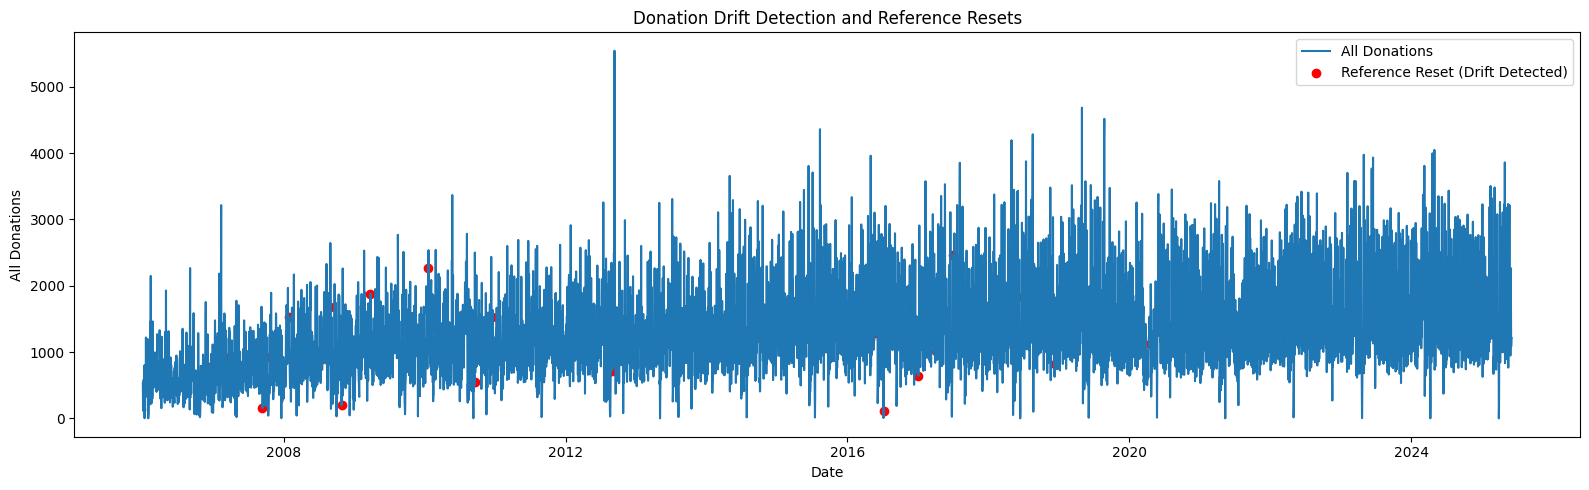

In [11]:
import matplotlib.pyplot as plt

# Prepare data for plotting
all_values = df_all['all'].to_numpy()
dates = df_all['date'].to_numpy()
reset_points = []

reset_count = 0
chunk_size = 10
window_size = 90

# We'll collect the reset indices for visualization
for i in range(window_size, len(df_all) - window_size, chunk_size):
    test_data = df_all['all'][i:i+window_size]
    drift_detected = my_drift.detect_drift_single_window(test_data)
    if drift_detected['drift_detected']:
        print(f"Drift detected at positions {i} to {i+90}. Resetting reference data.")
        reset_points.append(i + window_size)  # Mark the end of the window
        my_drift.set_reference_data(test_data.to_numpy())
        reset_count += 1

# Plot
plt.figure(figsize=(16, 5))
plt.plot(dates, all_values, label='All Donations')
plt.scatter([dates[idx] for idx in reset_points], [all_values[idx] for idx in reset_points],
            color='red', marker='o', label='Reference Reset (Drift Detected)')
plt.title('Donation Drift Detection and Reference Resets')
plt.xlabel('Date')
plt.ylabel('All Donations')
plt.legend()
plt.tight_layout()
plt.show()